In [ ]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import gzip
import pickle

# ==========================================
# General Plotting Setup
# ==========================================
pd.options.mode.chained_assignment = None
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "savefig.dpi": 300
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

sns.set_style('ticks', {'font.family': 'Times New Roman', 'font.serif': 'Times New Roman'})
sns.set_context('paper', font_scale=2.0)

colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}
y_DM_dict = {'1-loop VLF': 3.3, '1-loop Scalar': 7.2}

In [2]:
def plot_from_cache(cache_filename='histogram_cache.pkl.gz'):
    """Loads only the light cached file and renders matplotlib figures."""
    with gzip.open(cache_filename, 'rb') as f:
        all_plot_data = pickle.load(f)

    for entry in all_plot_data:
        bins = entry['bins']
        x_centers = (bins[:-1] + bins[1:]) / 2.0
        h_sm = entry['h_sm']
        hErr_sm = entry['hErr_sm']
        bsm_items = entry['bsm_items']

        fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
        plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

        # 1. Plot SM
        axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                      color=color_map['SM'], alpha=0.3, histtype='step', 
                      linewidth=0.0, fill=True, zorder=0, label='SM')

        bsm_hists, bsm_errs, bsm_labels = [], [], []

        # 2. Plot BSM & Z'
        for item in bsm_items:
            display_name = item['display_name']
            h_bsm = item['hist']
            hErr_bsm = item['err']
            
            bsm_hists.append(h_bsm)
            bsm_errs.append(hErr_bsm)
            bsm_labels.append(display_name)

            if display_name == 'Zprime':
                label_str = r'$Z^\prime$'
            else:
                label_str = rf'{display_name}, $y_{{DM}} = {item["val_y_dm"]:.1f}$'

            axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                          color=color_map[display_name], alpha=1.0, histtype='step', 
                          linewidth=2, fill=False, zorder=3, label=label_str)

        # 3. Ratio Subplot Calculations
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
            err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
            err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
            ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

        for k, r in enumerate(raw_ratio):
            axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                              fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
            axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]])

        # 4. Axis Limits & Formatting
        title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {entry["mPsiT"]:.0f}$ GeV; '
                     rf'$m_{{\phi}} = m_\chi = {entry["mSDM"]:.0f}$ GeV,' + '\n' +
                     rf'$m_{{Z^\prime}} = {entry["mZp"]:.1f}$ GeV; $\Gamma_{{Z^\prime}} = {entry["wZp"]:.1f}$ GeV')
        
        axarr[0].set_title(title_str, loc='left', pad=15)
        axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
        axarr[0].set_yscale('log')
        axarr[0].set_ylabel(entry['y_label'], fontsize=27)
        axarr[0].set_xlim(bins.min(), bins.max())
        axarr[0].set_ylim(entry['y_limits'])
        axarr[0].tick_params(axis='both', width=1, labelsize=20)

        axarr[1].axhline(y=0, color='k', linestyle='--')
        axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
        axarr[1].set_xlabel(entry['x_label'], fontsize=25)
        axarr[1].set_ylim(entry['ratio_limits'])
        axarr[1].set_yticks(entry['ratio_ticks'])
        axarr[1].grid(True)
        axarr[1].tick_params(axis='both', width=1, labelsize=20)

        plt.tight_layout()
        plt.savefig(entry['filename'])
        plt.show()
        print(f"Generated plot: {entry['filename']}")

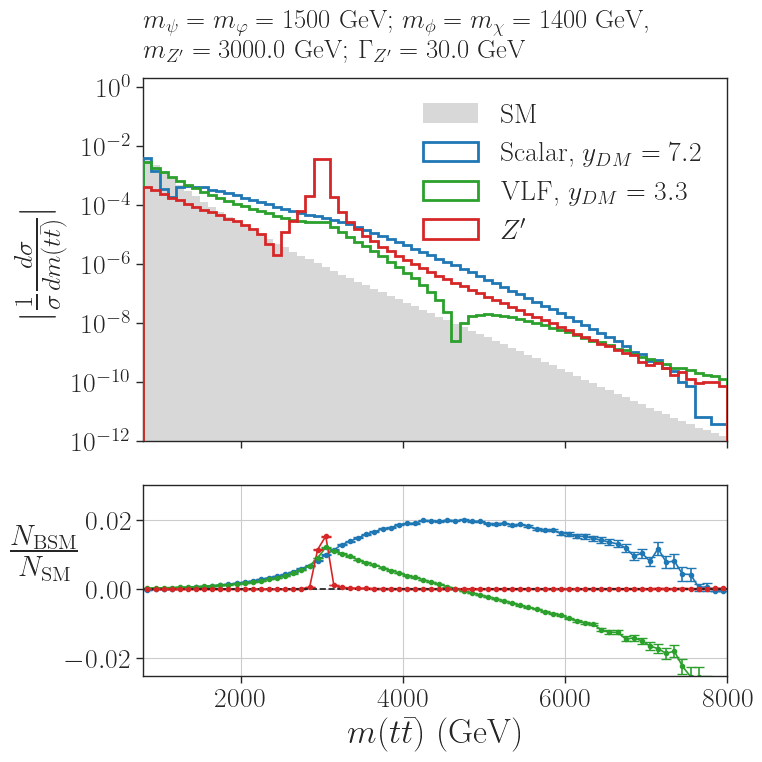

Generated plot: Dists_comparison_interference.png


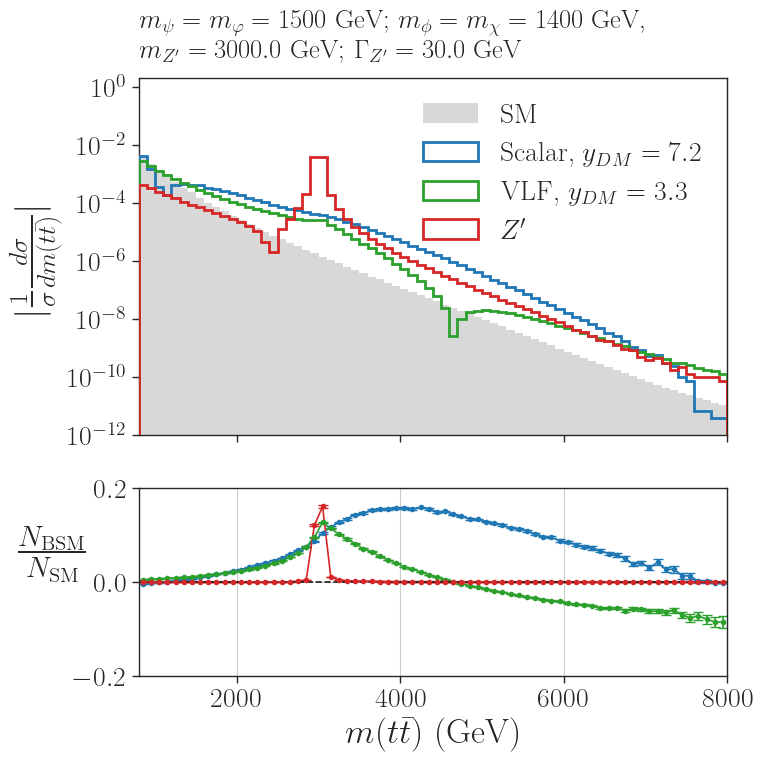

Generated plot: Dists_comparison_qq.png


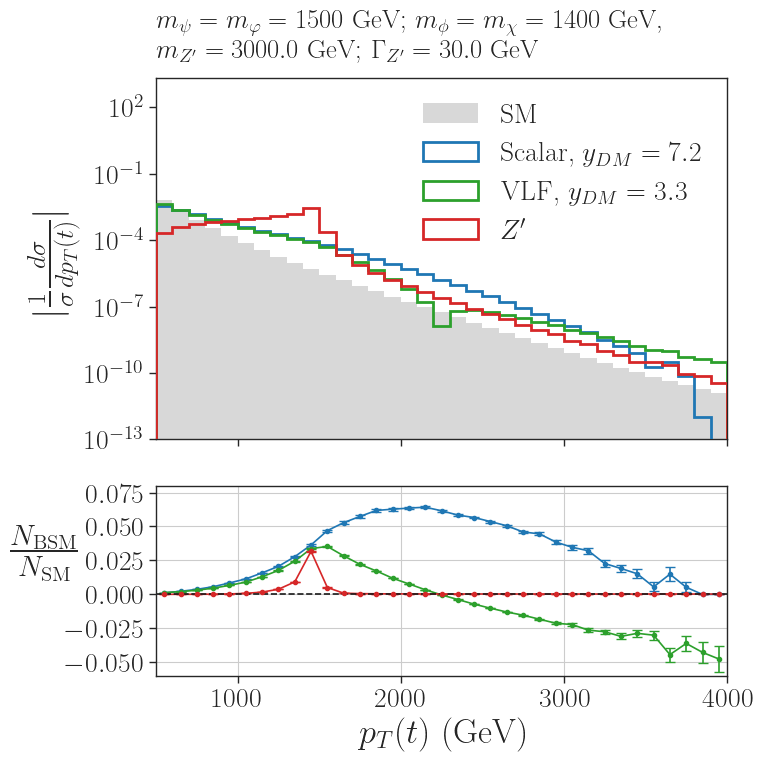

Generated plot: Dists_comparison_pT.png


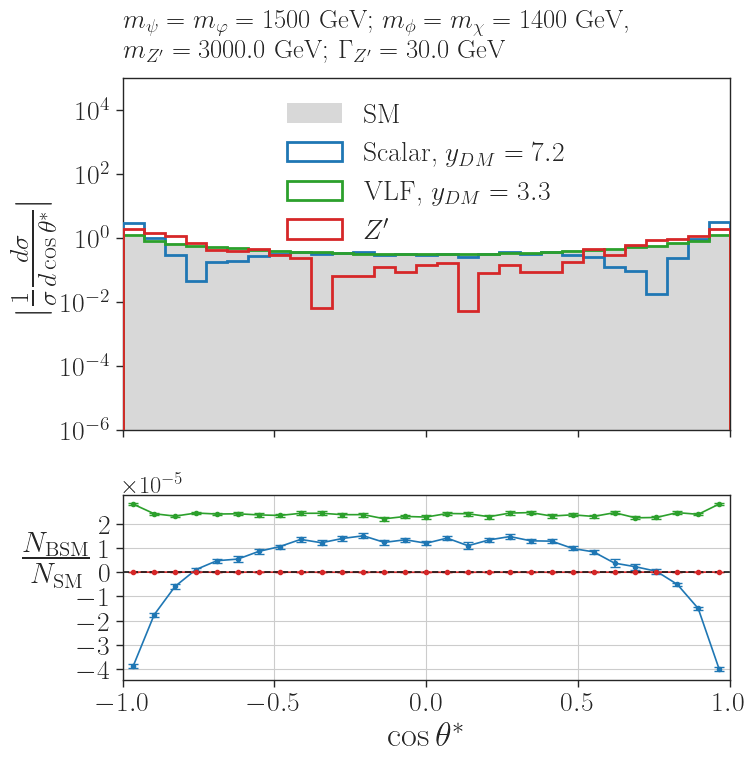

Generated plot: Dists_comparison_cost.png


In [3]:
file = './Differential_distributions_histograms.pkl.gz'

plot_from_cache(cache_filename=file)

In [4]:
import numpy as np
import glob

# Define the variables and the bin edges you want to use for all models
variables_to_plot = {
    'mTT': np.linspace(300, 3000, 50),
    'pT1': np.linspace(0, 1000, 50),
    'pT2': np.linspace(0, 1000, 50),
    'deltaPhi': np.linspace(0, np.pi, 30)
}

# Dictionary to hold the minimal data before saving
minimal_histograms = {}

# Store the shared bin edges once to save space
for var, bins in variables_to_plot.items():
    minimal_histograms[f'bins_{var}'] = bins

# Retrieve your files

print(files)
files = (list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_paper_1500_1400/*1500*1400*.npz'))
print(files)
        )

for f in files:
    d = np.load(f, allow_pickle=True)
    
    # Extract identifiers to create a unique key for each model's histograms
    try:
        model_name = str(d['model'])
        mass_params = f"{d['mass_params'][0]}_{d['mass_params'][1]}"
        hist_key = f"{model_name}_{mass_params}"
    except KeyError:
        # Fallback if specific keys aren't in a particular file
        hist_key = f.split('/')[-1].replace('.npz', '')

    weights = d['weights']
    
    # Compute and store the histogram counts for each variable
    for var, bins in variables_to_plot.items():
        if var in d:
            counts, _ = np.histogram(d[var], bins=bins, weights=weights)
            minimal_histograms[f'counts_{var}_{hist_key}'] = counts
    
    d.close() # Close the file to free up memory

# Save all pre-computed histograms to a single, highly compressed file
np.savez_compressed('compiled_histograms_minimal.npz', **minimal_histograms)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (322293006.py, line 22)

# Combining the process to obtain $pp \to t\bar{t}$

In [ ]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_paper_1500_1400/*1500*1400*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/*/*/mass_scan/*1500*1400*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz']
[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_paper_1500_1400/mPsiT_1500_mSDM_1400.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Dist

In [ ]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/SM/pp2ttbar_gs4/*.npz'))
sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*/*.npz'))
data_sm_exp = []
data_qq_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        
for f in  sm_qq_files:
    aux = np.load(f, allow_pickle = True)
    data_qq_sm_exp.append(aux)

data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])

In [ ]:
data_NLO = []
for d in data:
    if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']:
        data_NLO.append(d)

data_NLO = sorted(data_NLO, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

In [ ]:
for d in data_NLO:
    print(d['nevents'])

878395
1006181
1202163
3373384


In [ ]:

files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/Zprime/mass_scan/*3000*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/test/Distributions/*/*/*.npz'))
data_Z = []
#data_sm = []
#Loading the distributions
for f in files:
    aux = np.load(f, allow_pickle = True)
    data_Z.append(aux)

data_Z = sorted(data_Z, key=lambda d: d['mZp'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/Zprime/mass_scan/mZp_3000.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/Zprime/mass_scan/qed_int_mZp_3000.npz']


In [ ]:
print(data_Z[1])

NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/Zprime/mass_scan/qed_int_mZp_3000.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...


1-loop Scalar total sum: -0.002322099484882382
1-loop VLF total sum: 0.022643578385571066
Zprime mass masked sum: 0.0001414069290796291, total: 0.00012666870860808123


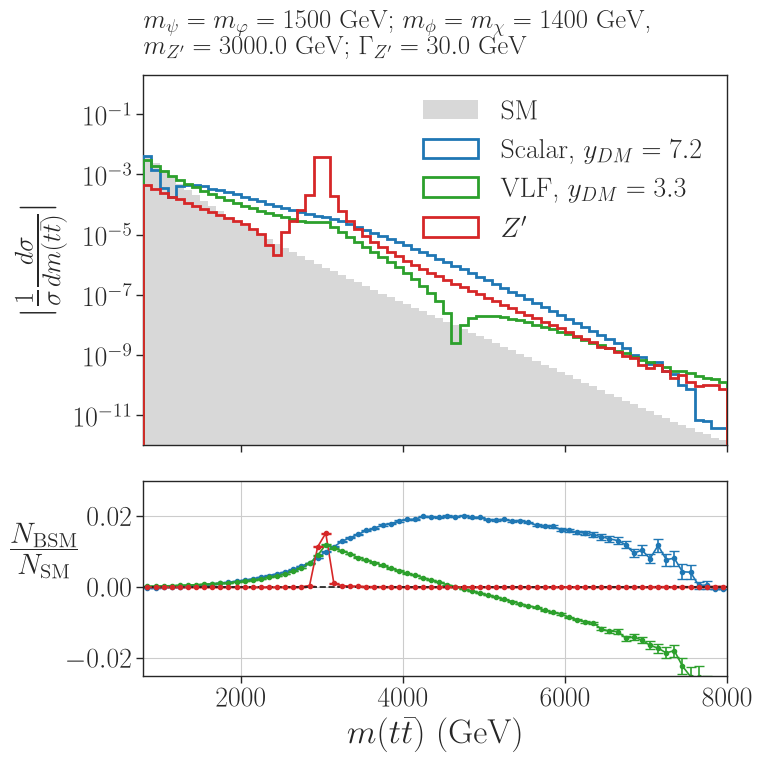

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Helper Functions
# ==========================================
def compute_hist(data_list, bins, weight_factor=1.0, z_prime = False):
    """Computes the histogram and its statistical error (sqrt of sum of squared weights)."""
    h_total = np.zeros(len(bins) - 1)
    hErr_sq_total = np.zeros(len(bins) - 1)
    
    for i,d in enumerate(data_list):
        if z_prime and i==1: weight_factor = np.sqrt(weight_factor)
        weights = np.array(d['weights']) * weight_factor
        h, _ = np.histogram(d['mTT'], bins=bins, weights=weights)
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=weights**2)
        h_total += h
        hErr_sq_total += hErr_sq
        
    return h_total, np.sqrt(hErr_sq_total)

# ==========================================
# General Configuration
# ==========================================
colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}

y_DM_dict = {'1-loop VLF': 3.3, '1-loop Scalar': 7.24}

# ==========================================
# Main Processing Loop
# ==========================================
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # Extract Physics Parameters
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # ------------------------------------------
    # 1. Setup and Binning
    # ------------------------------------------
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

 

    bins = np.arange(800., 8100., 100.)
        
    x_centers = (bins[:-1] + bins[1:]) / 2.0  
    
    # Storage for ratio plot
    bsm_hists, bsm_errs, bsm_labels = [], [], []

    # ------------------------------------------
    #  Process Standard Model (SM)
    # ------------------------------------------
    h_sm, hErr_sm = compute_hist(data_sm_exp, bins)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                  color=color_map['SM'], alpha=0.3, histtype='step', 
                  linewidth=0.0, fill=True, zorder=0, label='SM')

    # ------------------------------------------
    #  Process NLO BSM Data (Summing qq + gg)
    # ------------------------------------------
    for j in range(0, len(selected), 2):
        d_qq = selected[j]
        d_gg = selected[j+1]
        
        # Format model names
        model_raw = d_qq['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        
        # Get Couplings and scale factor
        val_y_dm = y_DM_dict.get(model_name, 1.0)
        scale_weight = val_y_dm**2 
        
        # Calculate Histograms for qq and gg, then combine
        h_bsm, hErr_bsm = compute_hist([d_qq, d_gg], bins, weight_factor=scale_weight)

        # Store for ratio plot
        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(display_name)
        
        print(f"{model_raw} total sum: {np.sum(h_bsm)}")

        # Plot Upper Panel
        label_str = rf'{display_name}, $y_{{DM}} = {val_y_dm:.1f}$'
        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                      color=color_map[display_name], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=label_str)

    # ------------------------------------------
    #  Process Z' 
    # ------------------------------------------
    if len(data_Z) > 0:
        h_z, hErr_z = compute_hist(data_Z, bins, weight_factor=(0.26**2), z_prime = True)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append('Zprime')
        
        mass_mask = (bins[:-1] >= 1000) & (bins[:-1] <= 5000)
        print(f"Zprime mass masked sum: {np.sum(h_z[mass_mask])}, total: {np.sum(h_z)}")

        axarr[0].hist(bins[:-1], weights=np.abs(h_z), bins=bins, density=True,
                      color=color_map['Zprime'], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=r'$Z^\prime$')

    # ------------------------------------------
    #  Process Ratio (Subplot)
    # ------------------------------------------
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        # Propagate errors for the ratio (sigma_R / R = sqrt((sigma_A/A)^2 + (sigma_B/B)^2))
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(raw_ratio):
        plot_color = color_map[bsm_labels[k]]
        axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=plot_color, 
                          fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x_centers, r, color=plot_color)

    # ------------------------------------------
    #  Plot Formatting & Beautification
    # ------------------------------------------
    
    # Upper Plot Config
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    
    title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {mPsiT:.0f}$ GeV; '
                 rf'$m_{{\phi}} = m_\chi = {mSDM:.0f}$ GeV,' + '\n' +
                 rf'$m_{{Z^\prime}} = {mZp:.1f}$ GeV; $\Gamma_{{Z^\prime}} = 30.0$ GeV')
    
    axarr[0].set_title(title_str, loc='left', pad=15)
    axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right', fontsize=20)
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$', fontsize=27)
    axarr[0].set_xlim(bins.min(), bins.max())
    axarr[0].set_ylim(1e-12, 2e-0)
    axarr[0].tick_params(axis='both', width=1, labelsize=20)

    # Bottom Plot Config
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=25)
    axarr[1].set_ylim([-0.025, 0.03])
    axarr[1].set_yticks(np.arange(-0.02, 0.03, 0.02))
    axarr[1].grid(True)
    axarr[1].tick_params(axis='both', width=1, labelsize=20)

    # Save and Show
    plt.tight_layout()
    plt.savefig('Dists_comparison_interference.png')
    plt.show()

1-loop Scalar total sum: 0.020471616179799056
1-loop VLF total sum: 0.016705261380403204
Zprime mass masked sum: 0.0001414069290796291, total: 0.00012666870860808123


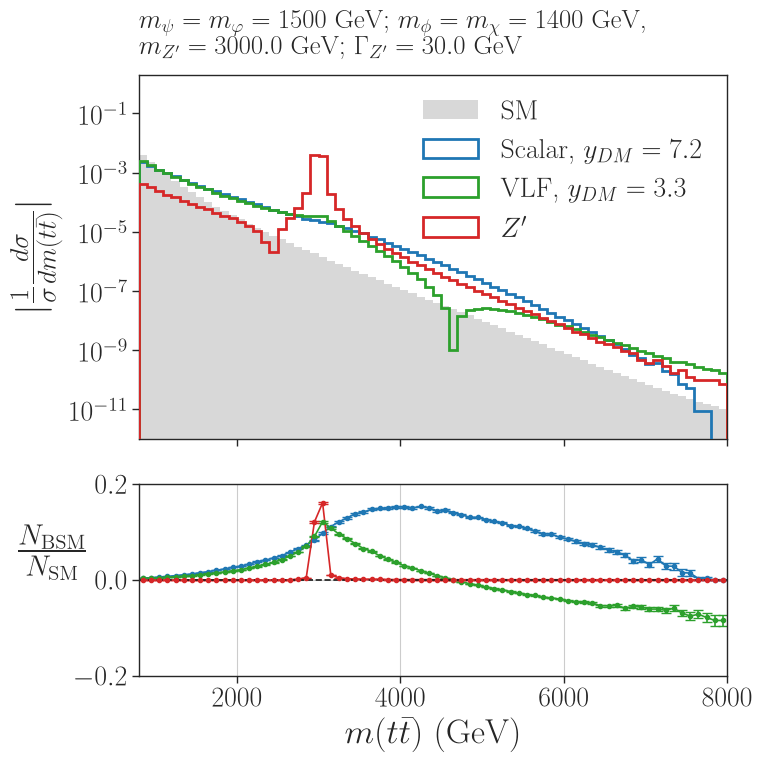

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Helper Functions
# ==========================================
def compute_hist(data_list, bins, weight_factor=1.0, z_prime = False):
    """Computes the histogram and its statistical error (sqrt of sum of squared weights)."""
    h_total = np.zeros(len(bins) - 1)
    hErr_sq_total = np.zeros(len(bins) - 1)
    
    for i,d in enumerate(data_list):
        if z_prime and i==1: weight_factor = np.sqrt(weight_factor)
        elif i == 1: break
        weights = np.array(d['weights']) * weight_factor
        h, _ = np.histogram(d['mTT'], bins=bins, weights=weights)
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=weights**2)
        h_total += h
        hErr_sq_total += hErr_sq
        
    return h_total, np.sqrt(hErr_sq_total)

# ==========================================
# General Configuration
# ==========================================
colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}

y_DM_dict = {'1-loop VLF': 3.3, '1-loop Scalar': 7.2}

# ==========================================
# Main Processing Loop
# ==========================================
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # Extract Physics Parameters
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # ------------------------------------------
    # 1. Setup and Binning
    # ------------------------------------------
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

 

    bins = np.arange(800., 8100., 100.)
        
    x_centers = (bins[:-1] + bins[1:]) / 2.0  
    
    # Storage for ratio plot
    bsm_hists, bsm_errs, bsm_labels = [], [], []

    # ------------------------------------------
    #  Process Standard Model (SM)
    # ------------------------------------------
    h_sm, hErr_sm = compute_hist(data_qq_sm_exp, bins)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                  color=color_map['SM'], alpha=0.3, histtype='step', 
                  linewidth=0.0, fill=True, zorder=0, label='SM')

    # ------------------------------------------
    #  Process NLO BSM Data (Summing qq + gg)
    # ------------------------------------------
    for j in range(0, len(selected), 2):
        d_qq = selected[j]
        d_gg = selected[j+1]
        
        # Format model names
        model_raw = d_qq['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        
        # Get Couplings and scale factor
        val_y_dm = y_DM_dict.get(model_name, 1.0)
        scale_weight = val_y_dm**2 
        
        # Calculate Histograms for qq and gg, then combine
        h_bsm, hErr_bsm = compute_hist([d_qq, d_gg], bins, weight_factor=scale_weight)

        # Store for ratio plot
        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(display_name)
        
        print(f"{model_raw} total sum: {np.sum(h_bsm)}")

        # Plot Upper Panel
        label_str = rf'{display_name}, $y_{{DM}} = {val_y_dm:.1f}$'
        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                      color=color_map[display_name], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=label_str)

    # ------------------------------------------
    #  Process Z' 
    # ------------------------------------------
    if len(data_Z) > 0:
        h_z, hErr_z = compute_hist(data_Z, bins, weight_factor=(0.26**2), z_prime = True)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append('Zprime')
        
        mass_mask = (bins[:-1] >= 1000) & (bins[:-1] <= 5000)
        print(f"Zprime mass masked sum: {np.sum(h_z[mass_mask])}, total: {np.sum(h_z)}")

        axarr[0].hist(bins[:-1], weights=np.abs(h_z), bins=bins, density=True,
                      color=color_map['Zprime'], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=r'$Z^\prime$')

    # ------------------------------------------
    #  Process Ratio (Subplot)
    # ------------------------------------------
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        # Propagate errors for the ratio (sigma_R / R = sqrt((sigma_A/A)^2 + (sigma_B/B)^2))
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(raw_ratio):
        plot_color = color_map[bsm_labels[k]]
        axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=plot_color, 
                          fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x_centers, r, color=plot_color)

    # ------------------------------------------
    #  Plot Formatting & Beautification
    # ------------------------------------------
    
    # Upper Plot Config
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    
    title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {mPsiT:.0f}$ GeV; '
                 rf'$m_{{\phi}} = m_\chi = {mSDM:.0f}$ GeV,' + '\n' +
                 rf'$m_{{Z^\prime}} = {mZp:.1f}$ GeV; $\Gamma_{{Z^\prime}} = 30.0$ GeV')
    
    axarr[0].set_title(title_str, loc='left', pad=15)
    axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right', fontsize=20)
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$', fontsize=27)
    axarr[0].set_xlim(bins.min(), bins.max())
    axarr[0].set_ylim(1e-12, 2e-0)
    axarr[0].tick_params(axis='both', width=1, labelsize=20)

    # Bottom Plot Config
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=25)
    axarr[1].set_ylim([-0.025, 0.03])
    axarr[1].set_yticks(np.arange(-0.2, 0.3, 0.2))
    axarr[1].grid(True)
    axarr[1].tick_params(axis='both', width=1, labelsize=20)

    # Save and Show
    plt.tight_layout()
    plt.savefig('Dists_comparison_qq.png')
    plt.show()

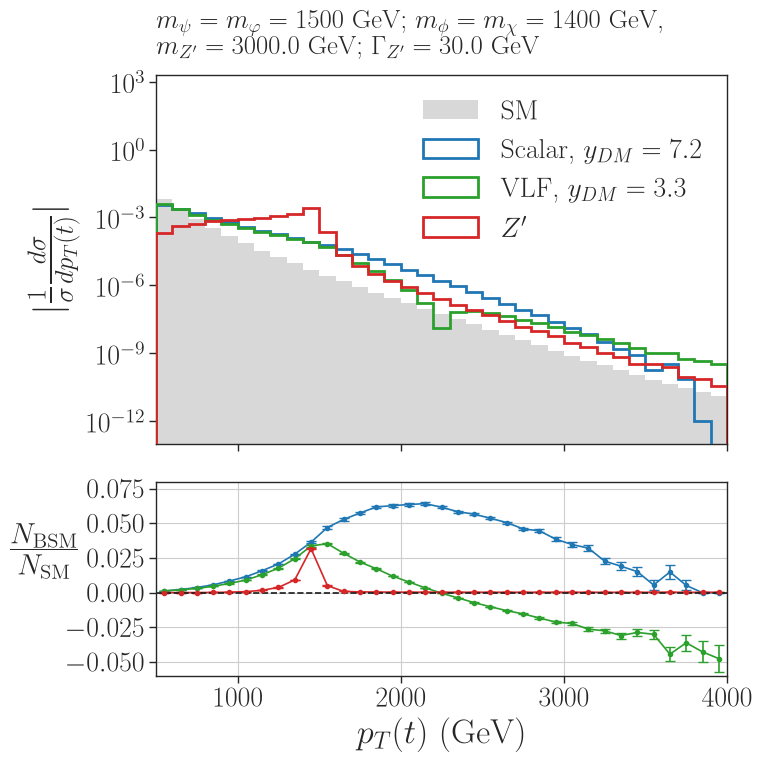

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Helper Functions
# ==========================================
def compute_hist(data_list, bins, var='pT', weight_factor=1.0, z_prime=False):
    """Computes the histogram and its statistical error (sqrt of sum of squared weights) for a given variable."""
    h_total = np.zeros(len(bins) - 1)
    hErr_sq_total = np.zeros(len(bins) - 1)
    
    for i, d in enumerate(data_list):
        current_weight_factor = weight_factor
        if z_prime and i == 1: 
            current_weight_factor = np.sqrt(weight_factor)
            
        weights = np.array(d['weights']) * current_weight_factor
        h, _ = np.histogram(d[var], bins=bins, weights=weights)
        hErr_sq, _ = np.histogram(d[var], bins=bins, weights=weights**2)
        
        h_total += h
        hErr_sq_total += hErr_sq
        
    return h_total, np.sqrt(hErr_sq_total)

# ==========================================
# General Configuration
# ==========================================
colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}

# Variable to plot
var = 'pT'

# Couplings for pT
y_DM_dict = {'1-loop VLF': 3.3, '1-loop Scalar': 7.2}

# ==========================================
# Main Processing Loop
# ==========================================
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # Extract Physics Parameters
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # ------------------------------------------
    # 1. Setup and Binning (pT Specific)
    # ------------------------------------------
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(500., 4100., 100.)
        
    x_centers = (bins[:-1] + bins[1:]) / 2.0  
    
    # Storage for ratio plot
    bsm_hists, bsm_errs, bsm_labels = [], [], []

    # ------------------------------------------
    # 2. Process Standard Model (SM)
    # ------------------------------------------
    h_sm, hErr_sm = compute_hist(data_sm_exp, bins, var=var)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                  color=color_map['SM'], alpha=0.3, histtype='step', 
                  linewidth=0.0, fill=True, zorder=0, label='SM')

    # ------------------------------------------
    # 3. Process NLO BSM Data (Summing qq + gg)
    # ------------------------------------------
    for j in range(0, len(selected), 2):
        d_qq = selected[j]
        d_gg = selected[j+1]
        
        # Format model names
        model_raw = d_qq['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        
        # Get Couplings and scale factor
        val_y_dm = y_DM_dict.get(model_name, 1.0)
        scale_weight = val_y_dm**2 
        
        # Calculate Histograms for qq and gg, then combine
        h_bsm, hErr_bsm = compute_hist([d_qq, d_gg], bins, var=var, weight_factor=scale_weight)

        # Store for ratio plot
        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(display_name)
        
        # Plot Upper Panel
        label_str = rf'{display_name}, $y_{{DM}} = {val_y_dm:.1f}$'
        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                      color=color_map[display_name], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=label_str)

    # ------------------------------------------
    # 4. Process Z' 
    # ------------------------------------------
    if len(data_Z) > 0:
        h_z, hErr_z = compute_hist(data_Z, bins, var=var, weight_factor=(0.26**2), z_prime=True)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append('Zprime')
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_z), bins=bins, density=True,
                      color=color_map['Zprime'], alpha=1.0, histtype='step', 
                      linewidth=2, fill=False, zorder=3, label=r'$Z^\prime$')

    # ------------------------------------------
    # 5. Process Ratio (Subplot)
    # ------------------------------------------
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        # Propagate errors for the ratio (sigma_R / R = sqrt((sigma_A/A)^2 + (sigma_B/B)^2))
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(raw_ratio):
        plot_color = color_map[bsm_labels[k]]
        axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=plot_color, 
                          fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x_centers, r, color=plot_color)

    # ------------------------------------------
    # 6. Plot Formatting & Beautification
    # ------------------------------------------
    
    # Upper Plot Config
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 30.0) if len(data_Z) > 0 else 30.0
    
    title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {mPsiT:.0f}$ GeV; '
                 rf'$m_{{\phi}} = m_\chi = {mSDM:.0f}$ GeV,' + '\n' +
                 rf'$m_{{Z^\prime}} = {mZp:.1f}$ GeV; $\Gamma_{{Z^\prime}} = {wZp:.1f}$ GeV')
    
    axarr[0].set_title(title_str, loc='left', pad=15)
    axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right', fontsize=20)
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d p_T(t)}|$', fontsize=27)
    axarr[0].set_xlim(bins.min(), bins.max())
    axarr[0].set_ylim(1e-13, 2e+3)
    axarr[0].tick_params(axis='both', width=1, labelsize=20)

    # Bottom Plot Config
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
    axarr[1].set_xlabel(r'$p_T(t)$ (GeV)', fontsize=25)
    axarr[1].set_ylim([-0.06, 0.08]) # Bounding strictly around the yticks
    axarr[1].set_yticks(np.arange(-0.05, 0.08, 0.025))
    axarr[1].grid(True)
    axarr[1].tick_params(axis='both', width=1, labelsize=20)

    # Save and Show
    plt.tight_layout()
    plt.savefig('Dists_comparison_pT.png')
    plt.show()

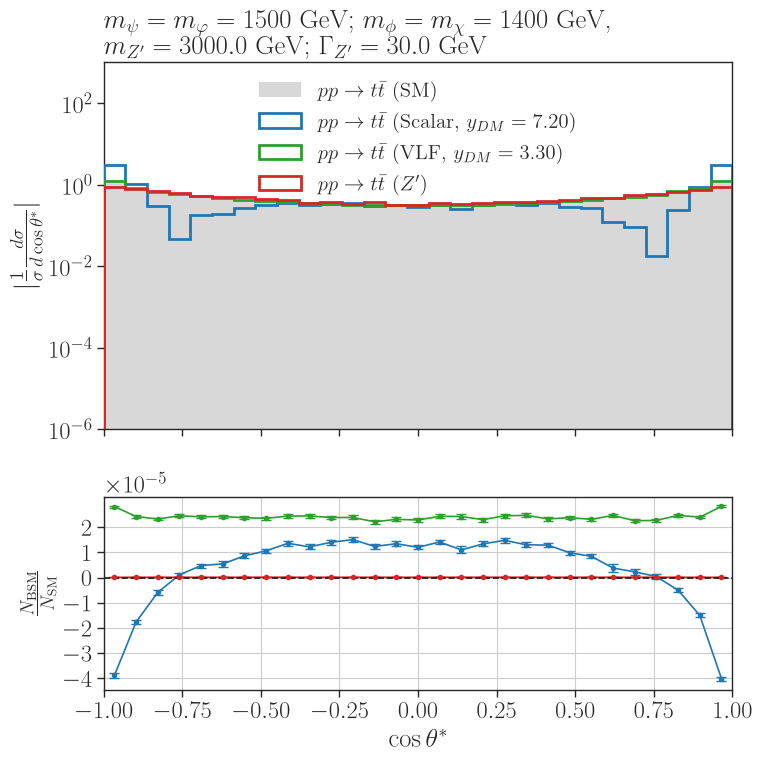

In [ ]:
# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)

var = 'cost*'
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

  
    bins = np.linspace(-1., 1., 30)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)
    bins_scaled = bins
    x_scaled = x
    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM 
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)
    
    for d in data_sm_exp:
        h, _ = np.histogram(d[var], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d[var], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_total += h
        hErr_sm_total_sq += hErr_sq
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    integral_sm = np.sum(h_sm_total)
    h_sm = h_sm_total #/ (integral_sm * bin_widths) if integral_sm > 0 else h_sm_total
    hErr_sm = np.sqrt(hErr_sm_total_sq) #/ (integral_sm * bin_widths) if integral_sm > 0 else np.sqrt(hErr_sm_total_sq)
    

    axarr[0].hist(bins_scaled[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins_scaled, density = True,
                  color=color_map['SM'], alpha=0.3, histtype='step', 
                  linewidth=0.0, fill=True, zorder=0)

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    y_DM = {'1-loop VLF': 3.3, '1-loop Scalar': 7.2}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        
        val_y_dm = y_DM.get(model_name, 1.0)
        

        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model, (mPsiT, mSDM))
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        h1, _ = np.histogram(d[var], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d[var], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next[var], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next[var], bins=bins, weights=np.array(d_next['weights'])**2)
        
        h_bsm_total = (h1 + h2) * scale_weight
        hErr_bsm_total_sq = (hErr1_sq + hErr2_sq)* (scale_weight**2)
        
        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total #/ (integral_bsm * bin_widths) if integral_bsm > 0 else h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq) #/ (integral_bsm * bin_widths) if integral_bsm > 0 else np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(display_name)
        bsm_colors.append(color)

        axarr[0].hist(bins_scaled[:-1], weights=np.abs(h_bsm), label=label, bins=bins_scaled,
                      color=color_map[display_name], alpha=1.0, histtype='step', density = True,
                      linewidth=2, fill=False, zorder=3)
        #axarr[0].errorbar(x, np.abs(h_bsm), yerr=hErr_bsm, color=color, 
         #                 fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=1.0)

   
    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d[var], bins=bins, weights=0.26**2 * d['weights'])
        hErr_sq, _ = np.histogram(d[var], bins=bins, weights=np.array(0.26**2 * d['weights'])**2)
        h_z_total += h
        hErr_z_total_sq += hErr_sq
        model_z = d['model']
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        integral_z = np.sum(h_z_total)
        h_z = h_z_total #/ (integral_z * bin_widths) if integral_z > 0 else h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq) #/ (integral_z * bin_widths) if integral_z > 0 else np.sqrt(hErr_z_total_sq)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append('Zprime')
        bsm_colors.append(color_z)
        
        axarr[0].hist(bins_scaled[:-1], weights=np.abs(h_z), label=label_z, bins=bins_scaled,
                      color=color_map['Zprime'], alpha=1.0, histtype='step', density = True,
                      linewidth=2, fill=False, zorder=3)
        #axarr[0].errorbar(x, np.abs(h_z), yerr=hErr_z, color=color_z, 
                         # fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=1.0)


    ############
    #  SUBPLOT #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate the raw ratio first to properly calculate the relative error
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        ratio = raw_ratio 
        
        # Propagate the errors for the ratio 
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)


    for k, r in enumerate(ratio):
        # Using errorbar for the ratio points to show the propagated MC uncertainty
        axarr[1].errorbar(x_scaled, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x_scaled, r, color=color_map[bsm_labels[k]]) # Add a line connecting points


    #################
    #  Plot configs #
    #################
    
    # Safely extract Z' properties
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=0.0, ncol=1, loc='upper center', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, ' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
        (mPsiT, mSDM, mZp, 30.0), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d \cos \theta^*}|$')
    axarr[0].set_xlim(bins_scaled.min(), bins_scaled.max())
    axarr[0].set_ylim(1e-6, 1e+3)

    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--') # Baseline is now at 0
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$\cos{\theta^*} $')
    axarr[1].grid(True)
    #axarr[1].set_yscale('symlog', linthresh = 1e-6)
    #axarr[1].set_ylim([-0.03, 0.03])
    #axarr[1].set_yticks(np.arange(-0.05,0.20, 0.05))
    axarr[1].set_yticks(np.arange(-4e-5,3e-5, 1e-5))
    #axarr[1].set_ylim([-0.025, 0.03])
    
    
   
    plt.tight_layout()
    #filename = f"mtt_pp_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}_ratio.png"
    plt.savefig('Dists_comparison_cost.png')
    plt.show()

Histograms successfully compiled and saved to 'Differential_distributions_histograms.pkl.gz'


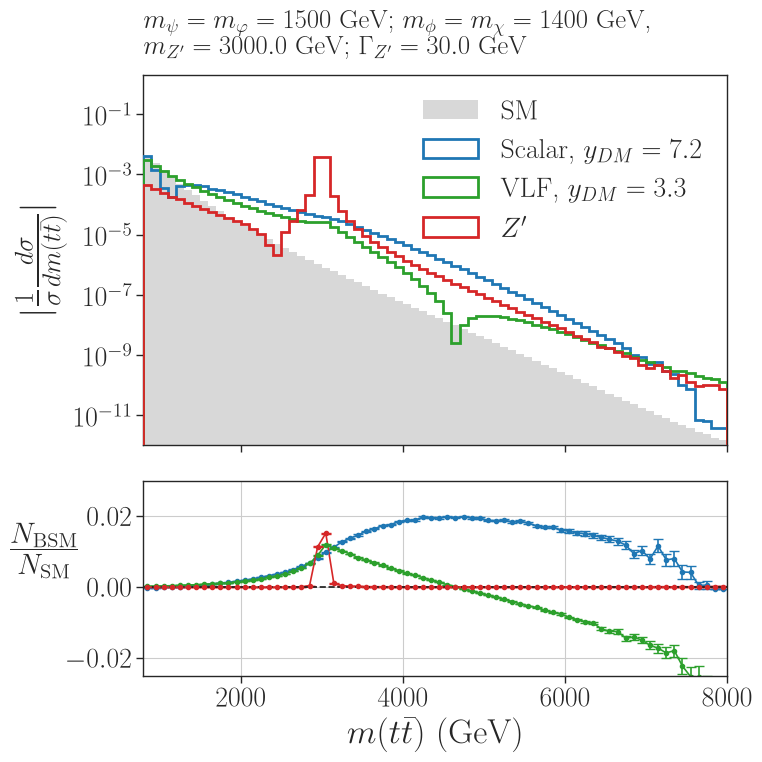

Generated plot: Dists_comparison_interference.png


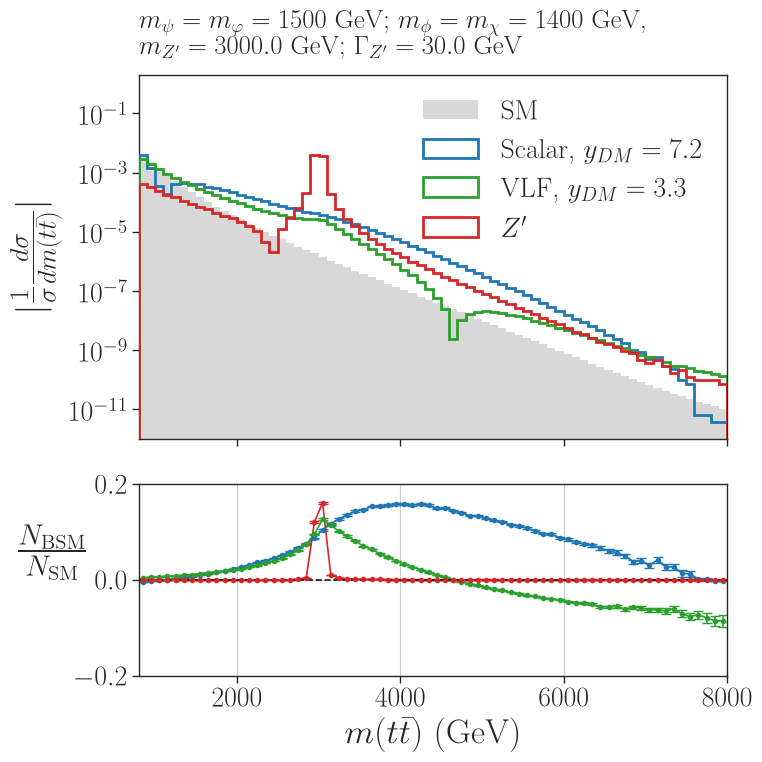

Generated plot: Dists_comparison_qq.png


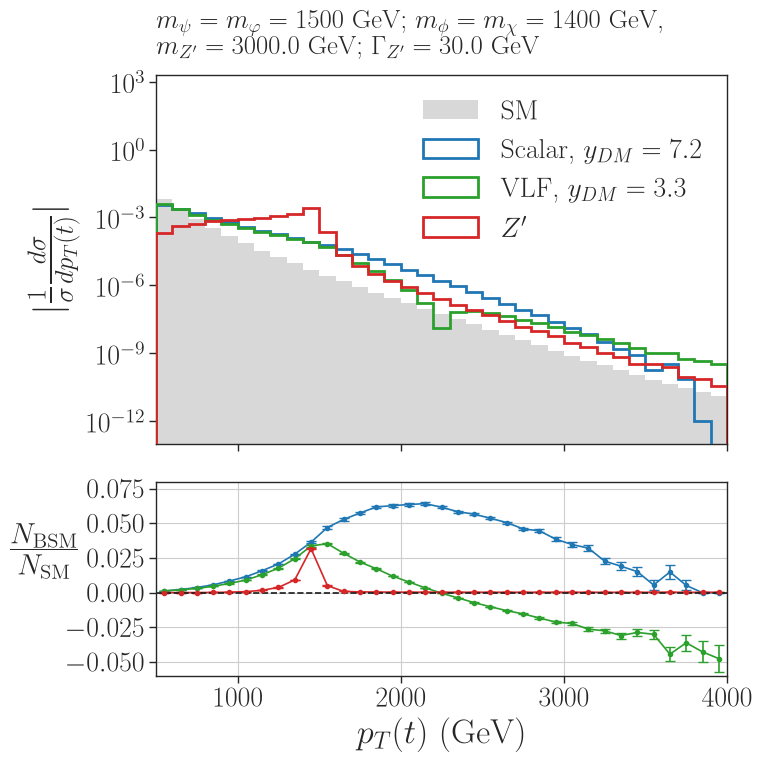

Generated plot: Dists_comparison_pT.png


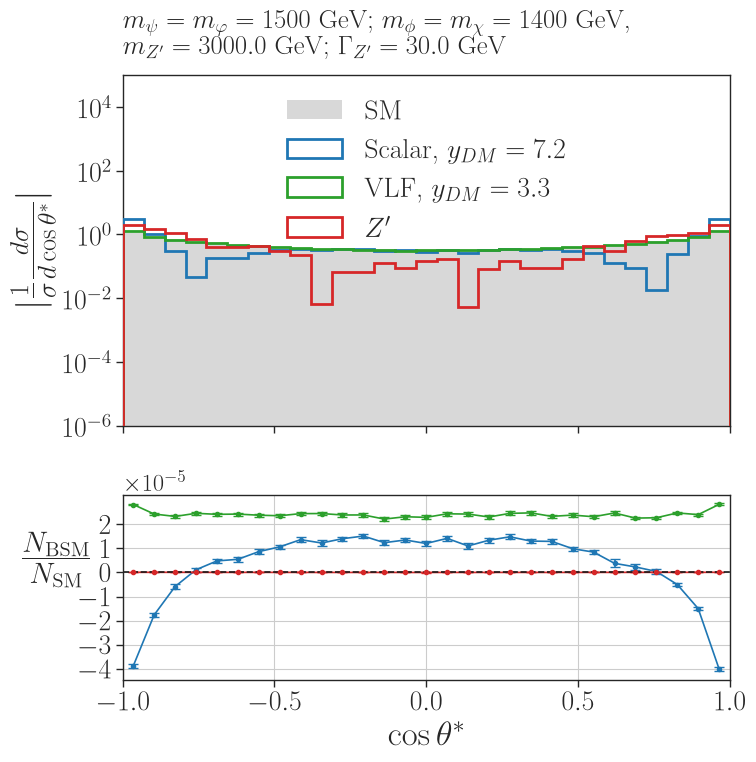

Generated plot: Dists_comparison_cost.png


In [ ]:



def load_raw_data():
    files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_paper_1500_1400/*1500*1400*.npz'))
    data = [np.load(f, allow_pickle=True) for f in files]
    data_NLO = sorted([d for d in data if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']], 
                      key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

    sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/SM/pp2ttbar_gs4/*.npz'))
    sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*/*.npz'))
    
    data_sm_exp = sorted([np.load(f, allow_pickle=True) for f in sm_files], key=lambda d: d['mass_params'][0])
    data_qq_sm_exp = [np.load(f, allow_pickle=True) for f in sm_qq_files]

    z_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/Zprime/mass_scan/*3000*.npz'))
    data_Z = sorted([np.load(f, allow_pickle=True) for f in z_files], key=lambda d: d['mZp'])

    return data_NLO, data_sm_exp, data_qq_sm_exp, data_Z

def compute_hist(data_list, bins, var='mTT', weight_factor=1.0, z_prime=False, is_sm=False):
    h_total = np.zeros(len(bins) - 1)
    hErr_sq_total = np.zeros(len(bins) - 1)
    
    for i, d in enumerate(data_list):
        current_weight = weight_factor
        if is_sm and i == 1 and var == 'mTT': 
            break
        if z_prime and i == 1: 
            current_weight = np.sqrt(weight_factor)
            
        weights = np.array(d['weights']) * current_weight
        h, _ = np.histogram(d[var], bins=bins, weights=weights)
        hErr_sq, _ = np.histogram(d[var], bins=bins, weights=weights**2)
        h_total += h
        hErr_sq_total += hErr_sq
        
    return h_total, np.sqrt(hErr_sq_total)

def precompute_and_save(cache_filename='histogram_cache.pkl.gz'):
    """Reads raw event files, calculates histograms, and saves them to a tiny file."""
    data_NLO, data_sm_exp, data_qq_sm_exp, data_Z = load_raw_data()
    all_plot_data = []

    for i in range(0, len(data_NLO), 4):
        selected = data_NLO[i : i+4]
        mPsiT, mSDM = selected[0]['mass_params']
        mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
        wZp = data_Z[0].get('wZp', 30.0) if len(data_Z) > 0 else 30.0

        bins_pt = np.arange(400., 3000., 50.) if mPsiT < 600 else (np.arange(500., 4000., 75.) if mPsiT < 1000 else np.arange(500., 4100., 100.))

        configs = [
            {
                'var': 'mTT', 'data_sm': data_sm_exp, 'is_sm_qq': False,
                'bins': np.arange(800., 8100., 100.),
                'y_limits': (1e-12, 2e-0), 'ratio_limits': [-0.025, 0.03], 'ratio_ticks': np.arange(-0.02, 0.03, 0.02),
                'y_label': r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$', 'x_label': r'$m(t\bar{t})$ (GeV)',
                'filename': 'Dists_comparison_interference.png'
            },
            {
                'var': 'mTT', 'data_sm': data_qq_sm_exp, 'is_sm_qq': True,
                'bins': np.arange(800., 8100., 100.),
                'y_limits': (1e-12, 2e-0), 'ratio_limits': [-0.025, 0.03], 'ratio_ticks': np.arange(-0.2, 0.3, 0.2),
                'y_label': r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$', 'x_label': r'$m(t\bar{t})$ (GeV)',
                'filename': 'Dists_comparison_qq.png'
            },
            {
                'var': 'pT', 'data_sm': data_sm_exp, 'is_sm_qq': False,
                'bins': bins_pt,
                'y_limits': (1e-13, 2e+3), 'ratio_limits': [-0.06, 0.08], 'ratio_ticks': np.arange(-0.05, 0.08, 0.025),
                'y_label': r'$|\frac{1}{\sigma}\frac{d \sigma}{d p_T(t)}|$', 'x_label': r'$p_T(t)$ (GeV)',
                'filename': 'Dists_comparison_pT.png'
            },
            {
                'var': 'cost*', 'data_sm': data_sm_exp, 'is_sm_qq': False,
                'bins': np.linspace(-1., 1., 30),
                'y_limits': (1e-6, 1e+5), 'ratio_limits': None, 'ratio_ticks': np.arange(-4e-5, 3e-5, 1e-5),
                'y_label': r'$|\frac{1}{\sigma}\frac{d \sigma}{d \cos{\theta^*}}|$', 'x_label': r'$\cos{\theta^*} $',
                'filename': 'Dists_comparison_cost.png'
            }
        ]

        for cfg in configs:
            bins = cfg['bins']
            var = cfg['var']
            
            # Compute SM histogram
            h_sm, hErr_sm = compute_hist(cfg['data_sm'], bins, var=var, is_sm=cfg['is_sm_qq'])

            # Compute BSM histograms
            bsm_items = []
            for j in range(0, len(selected), 2):
                d_qq, d_gg = selected[j], selected[j+1]
                model_name = str(np.atleast_1d(d_qq['model'])[0])
                display_name = model_name.replace('1-loop ', '')
                val_y_dm = y_DM_dict.get(model_name, 1.0)
                
                h_bsm, hErr_bsm = compute_hist([d_qq, d_gg], bins, var=var, weight_factor=(val_y_dm**2))
                
                bsm_items.append({
                    'display_name': display_name,
                    'val_y_dm': val_y_dm,
                    'hist': h_bsm,
                    'err': hErr_bsm
                })

            # Process Z' histogram
            if len(data_Z) > 0:
                h_z, hErr_z = compute_hist(data_Z, bins, var=var, weight_factor=(0.26**2), z_prime=True)
                bsm_items.append({
                    'display_name': 'Zprime',
                    'val_y_dm': None,
                    'hist': h_z,
                    'err': hErr_z
                })

            # Save minimal dictionary structure needed for plotting
            plot_entry = {
                'bins': bins,
                'h_sm': h_sm,
                'hErr_sm': hErr_sm,
                'bsm_items': bsm_items,
                'mPsiT': mPsiT, 'mSDM': mSDM, 'mZp': mZp, 'wZp': wZp,
                'var': var,
                'y_limits': cfg['y_limits'],
                'ratio_limits': cfg['ratio_limits'],
                'ratio_ticks': cfg['ratio_ticks'],
                'y_label': cfg['y_label'],
                'x_label': cfg['x_label'],
                'filename': cfg['filename']
            }
            all_plot_data.append(plot_entry)

    # Compress and save to disk
    with gzip.open(cache_filename, 'wb') as f:
        pickle.dump(all_plot_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Histograms successfully compiled and saved to '{cache_filename}'")

# ==========================================
# 2. Rendering Plots from Compressed File
# ==========================================
def plot_from_cache(cache_filename='histogram_cache.pkl.gz'):
    """Loads only the light cached file and renders matplotlib figures."""
    with gzip.open(cache_filename, 'rb') as f:
        all_plot_data = pickle.load(f)

    for entry in all_plot_data:
        bins = entry['bins']
        x_centers = (bins[:-1] + bins[1:]) / 2.0
        h_sm = entry['h_sm']
        hErr_sm = entry['hErr_sm']
        bsm_items = entry['bsm_items']

        fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
        plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

        # 1. Plot SM
        axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                      color=color_map['SM'], alpha=0.3, histtype='step', 
                      linewidth=0.0, fill=True, zorder=0, label='SM')

        bsm_hists, bsm_errs, bsm_labels = [], [], []

        # 2. Plot BSM & Z'
        for item in bsm_items:
            display_name = item['display_name']
            h_bsm = item['hist']
            hErr_bsm = item['err']
            
            bsm_hists.append(h_bsm)
            bsm_errs.append(hErr_bsm)
            bsm_labels.append(display_name)

            if display_name == 'Zprime':
                label_str = r'$Z^\prime$'
            else:
                label_str = rf'{display_name}, $y_{{DM}} = {item["val_y_dm"]:.1f}$'

            axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                          color=color_map[display_name], alpha=1.0, histtype='step', 
                          linewidth=2, fill=False, zorder=3, label=label_str)

        # 3. Ratio Subplot Calculations
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
            err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
            err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
            ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

        for k, r in enumerate(raw_ratio):
            axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                              fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
            axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]])

        # 4. Axis Limits & Formatting
        title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {entry["mPsiT"]:.0f}$ GeV; '
                     rf'$m_{{\phi}} = m_\chi = {entry["mSDM"]:.0f}$ GeV,' + '\n' +
                     rf'$m_{{Z^\prime}} = {entry["mZp"]:.1f}$ GeV; $\Gamma_{{Z^\prime}} = {entry["wZp"]:.1f}$ GeV')
        
        axarr[0].set_title(title_str, loc='left', pad=15)
        axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
        axarr[0].set_yscale('log')
        axarr[0].set_ylabel(entry['y_label'], fontsize=27)
        axarr[0].set_xlim(bins.min(), bins.max())
        axarr[0].set_ylim(entry['y_limits'])
        axarr[0].tick_params(axis='both', width=1, labelsize=20)

        axarr[1].axhline(y=0, color='k', linestyle='--')
        axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
        axarr[1].set_xlabel(entry['x_label'], fontsize=25)
        axarr[1].set_ylim(entry['ratio_limits'])
        axarr[1].set_yticks(entry['ratio_ticks'])
        axarr[1].grid(True)
        axarr[1].tick_params(axis='both', width=1, labelsize=20)

        plt.tight_layout()
        plt.savefig(entry['filename'])
        plt.show()
        print(f"Generated plot: {entry['filename']}")

# ==========================================
# Main Execution Pipeline
# ==========================================
if __name__ == '__main__':
    CACHE_FILE = 'Differential_distributions_histograms.pkl.gz'

    # STEP 1: Compute histograms from raw ROOT/npz files and store in a light format (Run once)
    precompute_and_save(cache_filename=CACHE_FILE)

    # STEP 2: Generate figures reading ONLY the lightweight cache file
    plot_from_cache(cache_filename=CACHE_FILE)